In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Base

In [21]:
base_path = Path('data/processed/base.parquet')
if not base_path.exists():
    base_path = Path('base.parquet')

base = pd.read_parquet(base_path)

In [22]:
base.head()

,subsystem_code,timestamp,load_mw,source_year,precipitation_mm,pressure_station_hpa,pressure_max_hpa,pressure_min_hpa,global_radiation_kj_m2,temperature_c,...,temperature_min_c,dew_point_max_c,dew_point_min_c,humidity_max_pct,humidity_min_pct,humidity_pct,wind_gust_ms,wind_speed_ms,wind_direction_deg,station_count
0,NE,2022-01-01 00:00:00,10508.822,2022,1.165217,974.582143,974.605357,973.880357,1.620000,23.971429,...,23.894643,20.936000,20.372000,82.680000,78.760000,82.392157,4.003704,1.503704,97.753149,144
1,NE,2022-01-01 01:00:00,10598.654,2022,0.339130,976.091379,976.155172,975.739655,68.233333,23.655172,...,23.581034,21.175472,20.639623,85.471698,81.981132,84.711538,4.121818,1.352727,104.333533,144
2,NE,2022-01-01 02:00:00,10625.716,2022,0.343478,973.700000,973.919298,973.631579,123.000000,23.119298,...,23.068421,21.048980,20.646939,87.208333,84.653061,86.937500,3.680000,1.287273,101.001139,144
3,NE,2022-01-01 03:00:00,10583.828,2022,0.097872,975.218966,975.636207,975.194828,457.171429,23.053448,...,22.996552,21.134000,20.800000,88.163265,85.959184,87.816327,3.430909,1.145455,96.908462,144
4,NE,2022-01-01 04:00:00,10495.137,2022,0.114894,973.732143,974.223214,973.712500,306.800000,22.785714,...,22.700000,21.095652,20.769565,88.777778,86.911111,88.444444,3.075472,1.056604,106.756377,144


In [23]:
base.tail()

,subsystem_code,timestamp,load_mw,source_year,precipitation_mm,pressure_station_hpa,pressure_max_hpa,pressure_min_hpa,global_radiation_kj_m2,temperature_c,...,temperature_min_c,dew_point_max_c,dew_point_min_c,humidity_max_pct,humidity_min_pct,humidity_pct,wind_gust_ms,wind_speed_ms,wind_direction_deg,station_count
40891,NE,2026-08-31 19:00:00,15309.979,2026,0.0,976.298649,976.432432,976.137838,1206.631944,31.134211,...,30.676316,17.229412,15.919118,46.811594,42.318841,45.246377,7.819118,3.167647,102.857044,140
40892,NE,2026-08-31 20:00:00,15255.274,2026,0.0,976.643243,976.656757,976.270270,525.047945,30.077632,...,30.010526,17.145588,16.001471,49.434783,44.159420,48.652174,7.513235,3.005882,102.949787,140
40893,NE,2026-08-31 21:00:00,15686.557,2026,0.0,977.532857,977.540000,977.131429,80.918571,28.388889,...,28.368056,17.210606,16.425758,54.029851,48.402985,53.121212,6.564063,2.329687,100.969863,140
40894,NE,2026-08-31 22:00:00,15660.982,2026,0.0,978.015714,978.022857,977.528571,11.789474,27.111111,...,27.045833,17.555385,16.753846,58.575758,52.848485,58.363636,5.456250,2.184375,107.139521,140
40895,NE,2026-08-31 23:00:00,15149.486,2026,0.0,979.294118,979.295588,978.605882,15.588889,26.190000,...,26.148571,18.057143,17.304762,63.171875,58.109375,62.750000,5.508065,2.029032,107.810911,140


In [24]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40896 entries, 0 to 40895
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   subsystem_code          40896 non-null  string        
 1   timestamp               40896 non-null  datetime64[us]
 2   load_mw                 40896 non-null  float64       
 3   source_year             40896 non-null  int64         
 4   precipitation_mm        40896 non-null  float64       
 5   pressure_station_hpa    40896 non-null  float64       
 6   pressure_max_hpa        40896 non-null  float64       
 7   pressure_min_hpa        40896 non-null  float64       
 8   global_radiation_kj_m2  40896 non-null  float64       
 9   temperature_c           40896 non-null  float64       
 10  dew_point_c             40896 non-null  float64       
 11  temperature_max_c       40896 non-null  float64       
 12  temperature_min_c       40896 non-null  float6

# Target

In [25]:
print(base['load_mw'].describe())

count    40896.000000
mean     12557.303667
std       1510.268967
min       7262.283000
25%      11528.348000
50%      12603.674500
75%      13665.218000
max      18156.972000
Name: load_mw, dtype: float64


## Evolução da carga ao longo do tempo

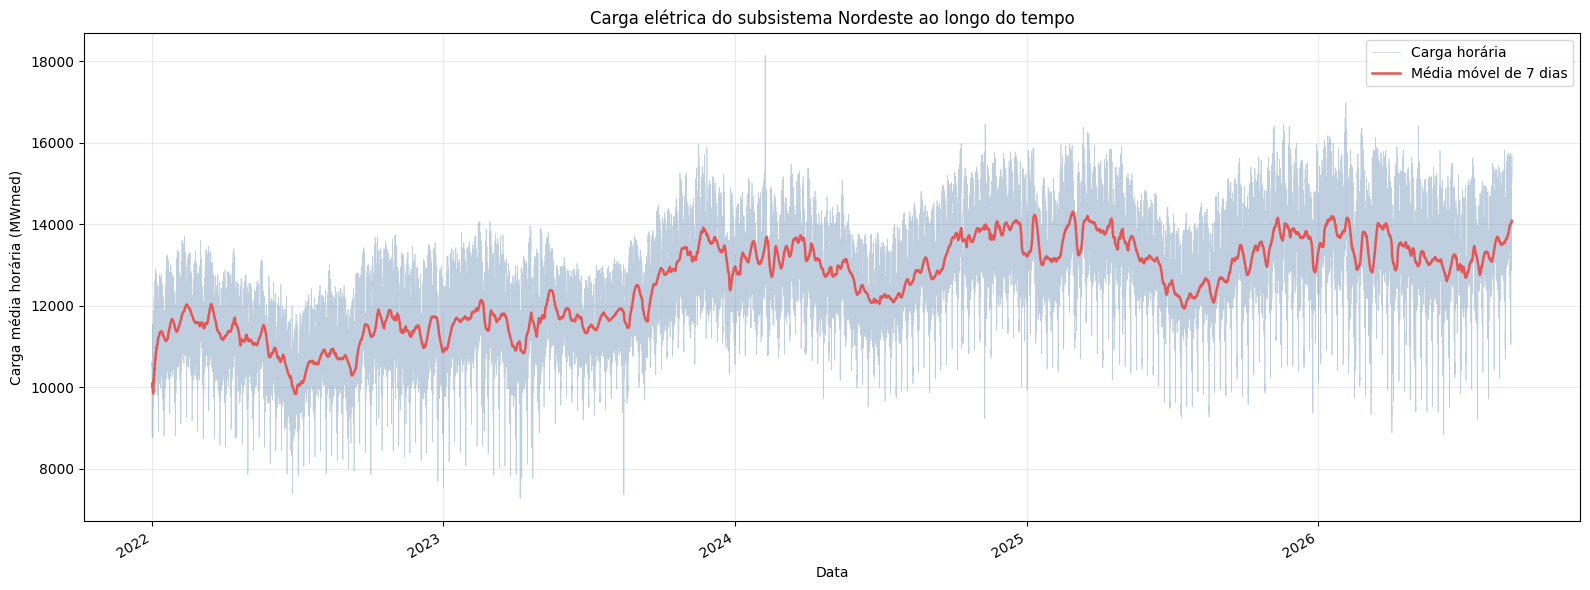

In [26]:
load_series = (
    base[['timestamp', 'load_mw']]
    .sort_values('timestamp')
    .set_index('timestamp')['load_mw']
)
load_rolling_7d = load_series.rolling('7D', min_periods=24).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    load_series.index,
    load_series,
    color='#4C78A8',
    linewidth=0.5,
    alpha=0.35,
    label='Carga horária',
)
ax.plot(
    load_rolling_7d.index,
    load_rolling_7d,
    color='#E45756',
    linewidth=1.8,
    label='Média móvel de 7 dias',
)

ax.set_title('Carga elétrica do subsistema Nordeste ao longo do tempo')
ax.set_xlabel('Data')
ax.set_ylabel('Carga média horária (MWmed)')
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Curva de carga média diária

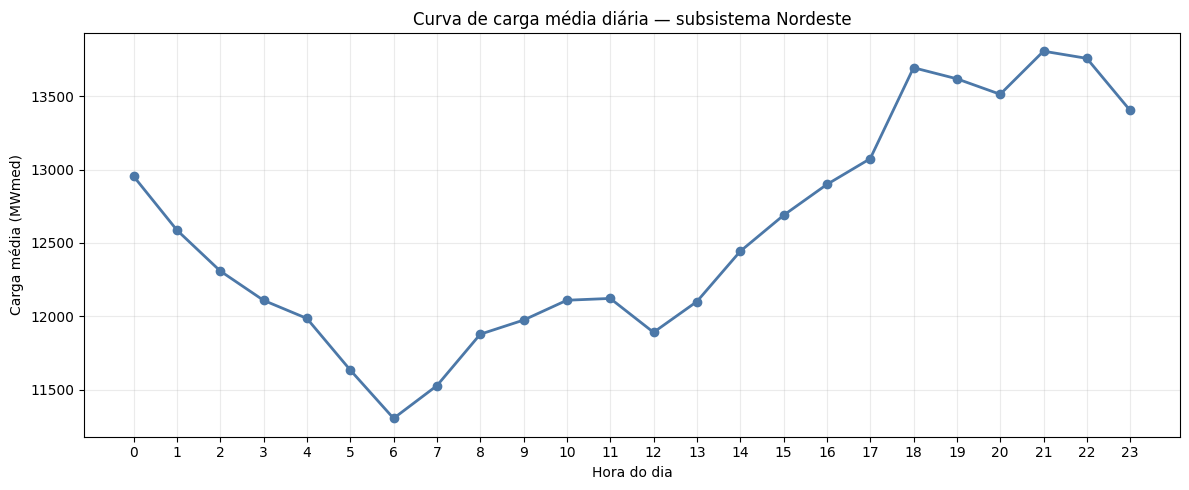

In [27]:
average_daily_load = (
    base.assign(hour=base['timestamp'].dt.hour)
    .groupby('hour', as_index=False)
    .agg(load_mw_mean=('load_mw', 'mean'))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    average_daily_load['hour'],
    average_daily_load['load_mw_mean'],
    color='#4C78A8',
    linewidth=2,
    marker='o',
)
ax.set_title('Curva de carga média diária — subsistema Nordeste')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Carga média (MWmed)')
ax.set_xticks(range(24))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Média máxima diaria 

In [31]:
average_daily_load['load_mw_mean'].idxmax(), average_daily_load['load_mw_mean'].max()

(21, 13833.981999995)

Média minima diaria

In [32]:
average_daily_load['load_mw_mean'].idxmin(), average_daily_load['load_mw_mean'].min()

(6, 11471.66199999)

## Curva de carga média por dia da semana

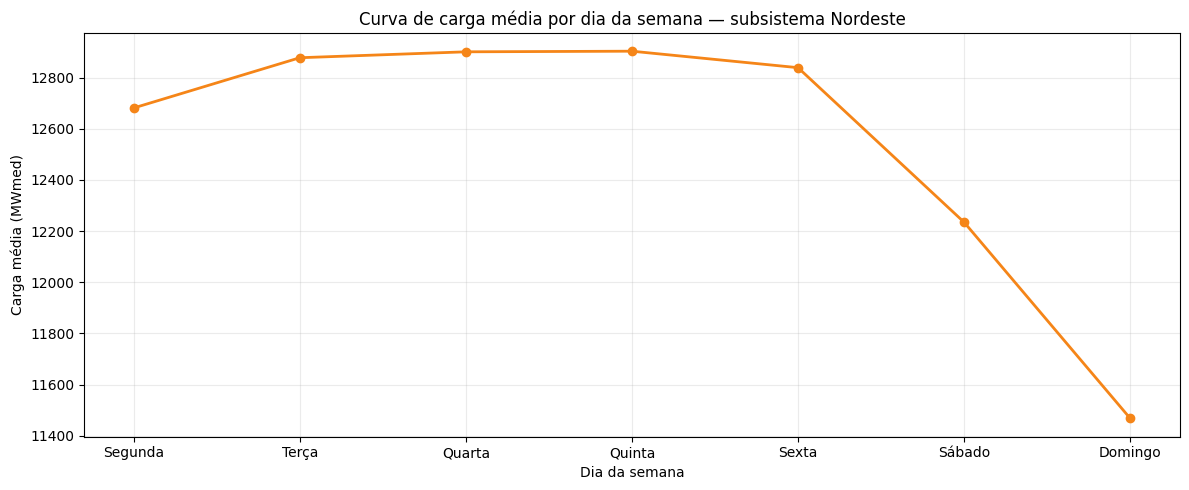

In [33]:
weekday_labels = {
    0: 'Segunda',
    1: 'Terça',
    2: 'Quarta',
    3: 'Quinta',
    4: 'Sexta',
    5: 'Sábado',
    6: 'Domingo',
}

average_weekday_load = (
    base.assign(day_of_week=base['timestamp'].dt.dayofweek)
    .groupby('day_of_week', as_index=False)
    .agg(load_mw_mean=('load_mw', 'mean'))
    .sort_values('day_of_week')
)
average_weekday_load['weekday'] = average_weekday_load['day_of_week'].map(weekday_labels)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    average_weekday_load['weekday'],
    average_weekday_load['load_mw_mean'],
    color='#F58518',
    linewidth=2,
    marker='o',
)
ax.set_title('Curva de carga média por dia da semana — subsistema Nordeste')
ax.set_xlabel('Dia da semana')
ax.set_ylabel('Carga média (MWmed)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Maiores e menores dias com carga média

In [35]:
menores_dias = average_weekday_load.nsmallest(3, 'load_mw_mean')
print("Os três dias da semana com menor carga média são:")
for index, row in menores_dias.iterrows():
    print(f"{row['weekday']}: {row['load_mw_mean']:.2f} MWmed")

Os três dias da semana com menor carga média são:
Domingo: 11468.11 MWmed
Sábado: 12234.84 MWmed
Segunda: 12681.62 MWmed


In [36]:
maiores_dias = average_weekday_load.nlargest(3, 'load_mw_mean')
print("Os três dias da semana com maior carga média são:")
for index, row in maiores_dias.iterrows():
    print(f"{row['weekday']}: {row['load_mw_mean']:.2f} MWmed")

Os três dias da semana com maior carga média são:
Quinta: 12903.57 MWmed
Quarta: 12901.14 MWmed
Terça: 12878.01 MWmed


## Curva de carga média mensal

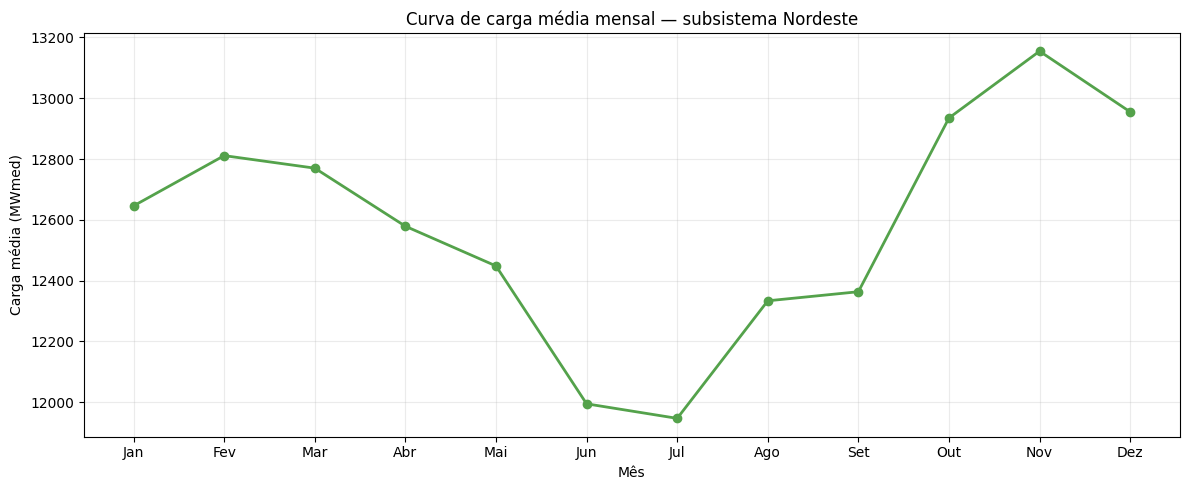

In [37]:
month_labels = {
    1: 'Jan',
    2: 'Fev',
    3: 'Mar',
    4: 'Abr',
    5: 'Mai',
    6: 'Jun',
    7: 'Jul',
    8: 'Ago',
    9: 'Set',
    10: 'Out',
    11: 'Nov',
    12: 'Dez',
}

average_monthly_load = (
    base.assign(month=base['timestamp'].dt.month)
    .groupby('month', as_index=False)
    .agg(load_mw_mean=('load_mw', 'mean'))
    .sort_values('month')
)
average_monthly_load['month_name'] = average_monthly_load['month'].map(month_labels)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    average_monthly_load['month_name'],
    average_monthly_load['load_mw_mean'],
    color='#54A24B',
    linewidth=2,
    marker='o',
)
ax.set_title('Curva de carga média mensal — subsistema Nordeste')
ax.set_xlabel('Mês')
ax.set_ylabel('Carga média (MWmed)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [38]:
maiores_meses = average_monthly_load.nlargest(6, 'load_mw_mean')
menores_meses = average_monthly_load.nsmallest(6, 'load_mw_mean')

print("Os seis meses com maior carga média são:")
for index, row in maiores_meses.iterrows():
    print(f"{row['month_name']}: {row['load_mw_mean']:.2f} MWmed")

print("Os seis meses com menor carga média são:")
for index, row in menores_meses.iterrows():
    print(f"{row['month_name']}: {row['load_mw_mean']:.2f} MWmed")

Os seis meses com maior carga média são:
Nov: 13154.86 MWmed
Dez: 12955.24 MWmed
Out: 12935.15 MWmed
Fev: 12811.34 MWmed
Mar: 12770.09 MWmed
Jan: 12646.06 MWmed
Os seis meses com menor carga média são:
Jul: 11947.04 MWmed
Jun: 11994.89 MWmed
Ago: 12333.77 MWmed
Set: 12363.62 MWmed
Mai: 12448.40 MWmed
Abr: 12579.04 MWmed


## Tendência e sazonalidade

/tmp/ipykernel_2808/3704608210.py:11: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  load_decomposition = seasonal_decompose(


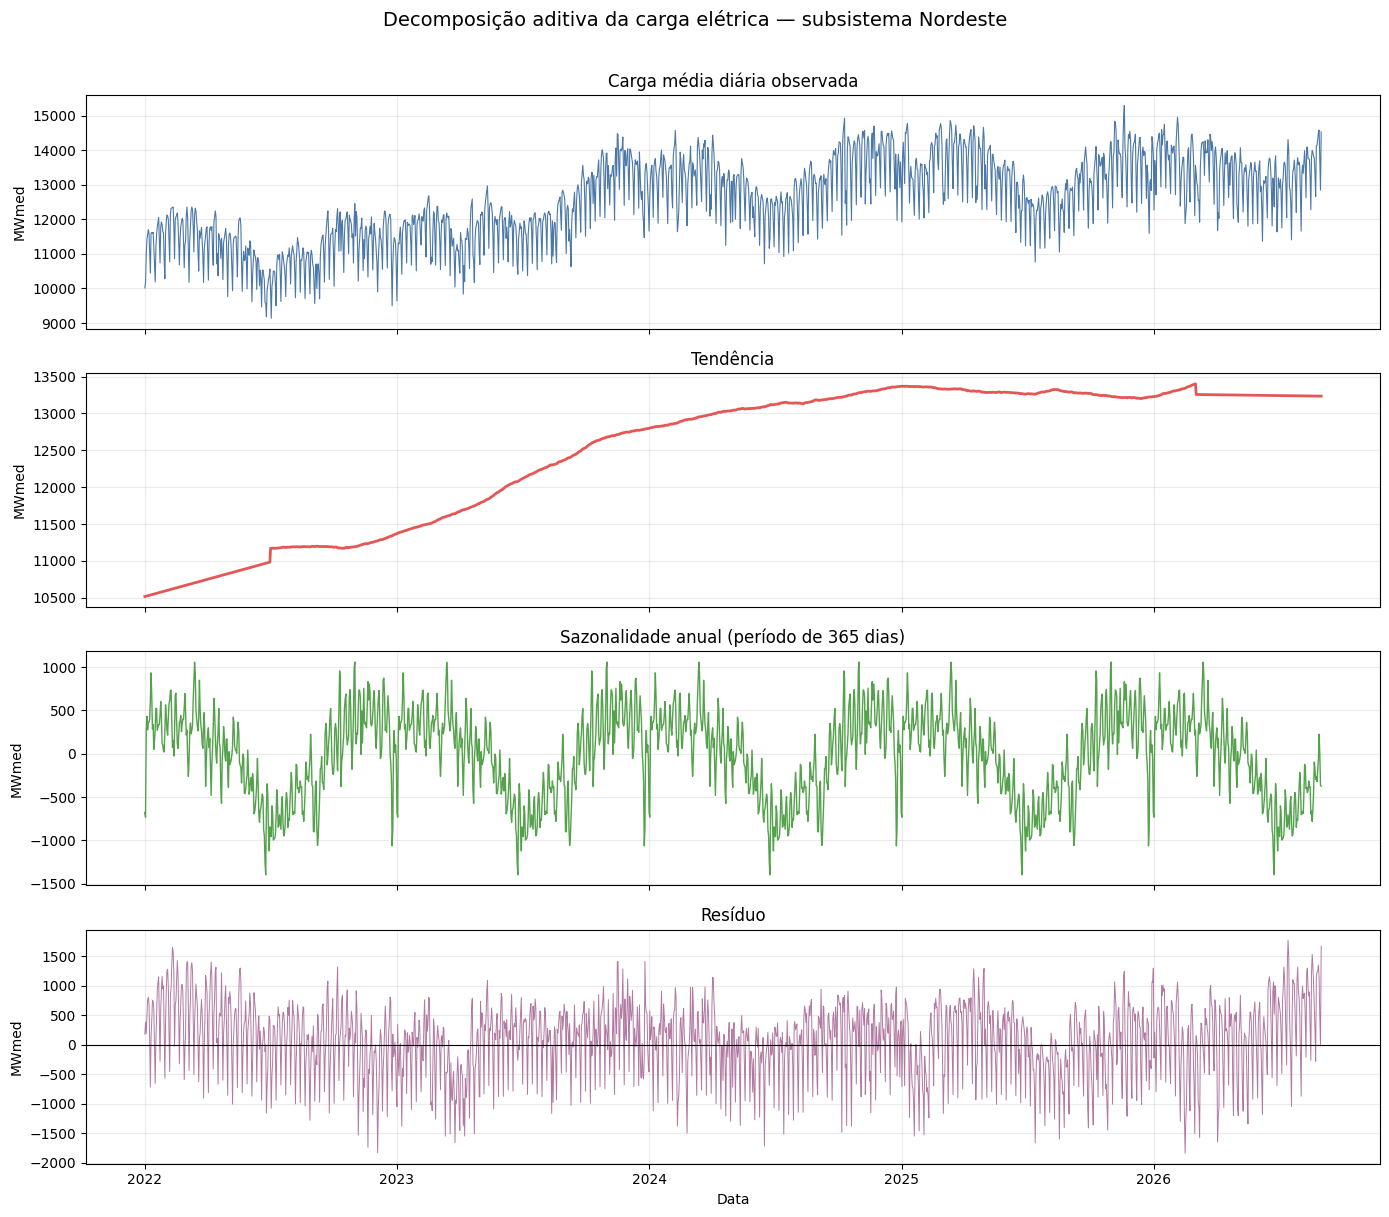

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_load_decompose = (
    base.set_index('timestamp')['load_mw']
    .resample('D')
    .mean()
    .asfreq('D')
    .interpolate(method='time')
)

load_decomposition = seasonal_decompose(
    daily_load_decompose,
    model='additive',
    period=365,
    extrapolate_trend='freq',
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(load_decomposition.observed, color='#4C78A8', linewidth=0.8)
axes[0].set_title('Carga média diária observada')
axes[0].set_ylabel('MWmed')

axes[1].plot(load_decomposition.trend, color='#E45756', linewidth=2)
axes[1].set_title('Tendência')
axes[1].set_ylabel('MWmed')

axes[2].plot(load_decomposition.seasonal, color='#54A24B', linewidth=1)
axes[2].set_title('Sazonalidade anual (período de 365 dias)')
axes[2].set_ylabel('MWmed')

axes[3].plot(load_decomposition.resid, color='#B279A2', linewidth=0.7)
axes[3].axhline(0, color='black', linewidth=0.8)
axes[3].set_title('Resíduo')
axes[3].set_xlabel('Data')
axes[3].set_ylabel('MWmed')

for ax in axes:
    ax.grid(True, alpha=0.25)

fig.suptitle(
    'Decomposição aditiva da carga elétrica — subsistema Nordeste',
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()

# Temperatura × carga

In [40]:
base.columns.to_list()

['subsystem_code',
 'timestamp',
 'load_mw',
 'source_year',
 'precipitation_mm',
 'pressure_station_hpa',
 'pressure_max_hpa',
 'pressure_min_hpa',
 'global_radiation_kj_m2',
 'temperature_c',
 'dew_point_c',
 'temperature_max_c',
 'temperature_min_c',
 'dew_point_max_c',
 'dew_point_min_c',
 'humidity_max_pct',
 'humidity_min_pct',
 'humidity_pct',
 'wind_gust_ms',
 'wind_speed_ms',
 'wind_direction_deg',
 'station_count']

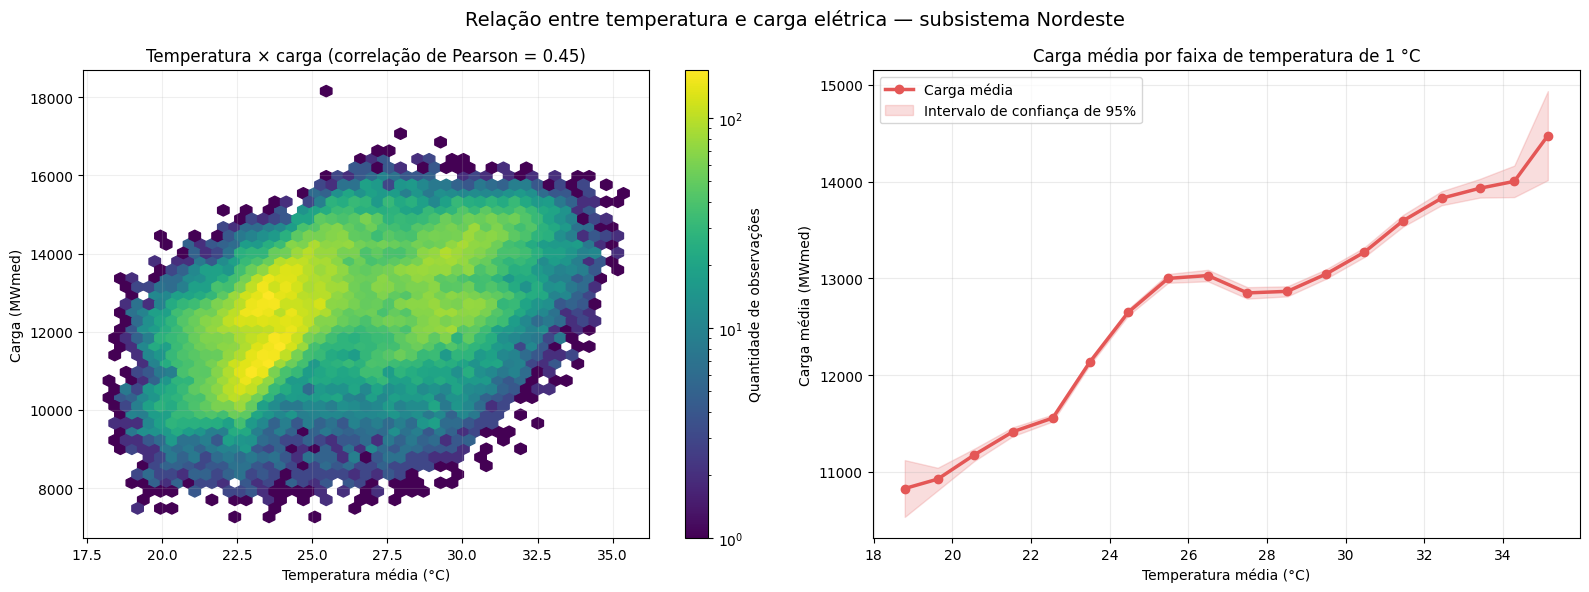

In [41]:
import numpy as np
import pandas as pd

temperature_load = (
    base[['temperature_c', 'load_mw']]
    .dropna()
    .copy()
)
temperature_correlation = temperature_load['temperature_c'].corr(
    temperature_load['load_mw']
)

temperature_bin_edges = np.arange(
    np.floor(temperature_load['temperature_c'].min()),
    np.ceil(temperature_load['temperature_c'].max()) + 1,
    1,
)
temperature_load['temperature_band'] = pd.cut(
    temperature_load['temperature_c'],
    bins=temperature_bin_edges,
    include_lowest=True,
)

temperature_curve = (
    temperature_load.groupby('temperature_band', observed=True)
    .agg(
        temperature_mean=('temperature_c', 'mean'),
        load_mw_mean=('load_mw', 'mean'),
        load_mw_std=('load_mw', 'std'),
        observations=('load_mw', 'size'),
    )
    .reset_index(drop=True)
)
temperature_curve['ci95'] = (
    1.96
    * temperature_curve['load_mw_std']
    / np.sqrt(temperature_curve['observations'])
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

density = axes[0].hexbin(
    temperature_load['temperature_c'],
    temperature_load['load_mw'],
    gridsize=45,
    mincnt=1,
    bins='log',
    cmap='viridis',
)
fig.colorbar(density, ax=axes[0], label='Quantidade de observações')
axes[0].set_title(
    f'Temperatura × carga (correlação de Pearson = {temperature_correlation:.2f})'
)
axes[0].set_xlabel('Temperatura média (°C)')
axes[0].set_ylabel('Carga (MWmed)')
axes[0].grid(True, alpha=0.2)

temperature_x = temperature_curve['temperature_mean'].to_numpy()
load_mean = temperature_curve['load_mw_mean'].to_numpy()
confidence = temperature_curve['ci95'].to_numpy()
axes[1].plot(
    temperature_x,
    load_mean,
    color='#E45756',
    linewidth=2.5,
    marker='o',
    label='Carga média',
)
axes[1].fill_between(
    temperature_x,
    load_mean - confidence,
    load_mean + confidence,
    color='#E45756',
    alpha=0.2,
    label='Intervalo de confiança de 95%',
)
axes[1].set_title('Carga média por faixa de temperatura de 1 °C')
axes[1].set_xlabel('Temperatura média (°C)')
axes[1].set_ylabel('Carga média (MWmed)')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

fig.suptitle('Relação entre temperatura e carga elétrica — subsistema Nordeste', fontsize=14)
plt.tight_layout()
plt.show()

## Heatmap da carga por dia da semana e hora

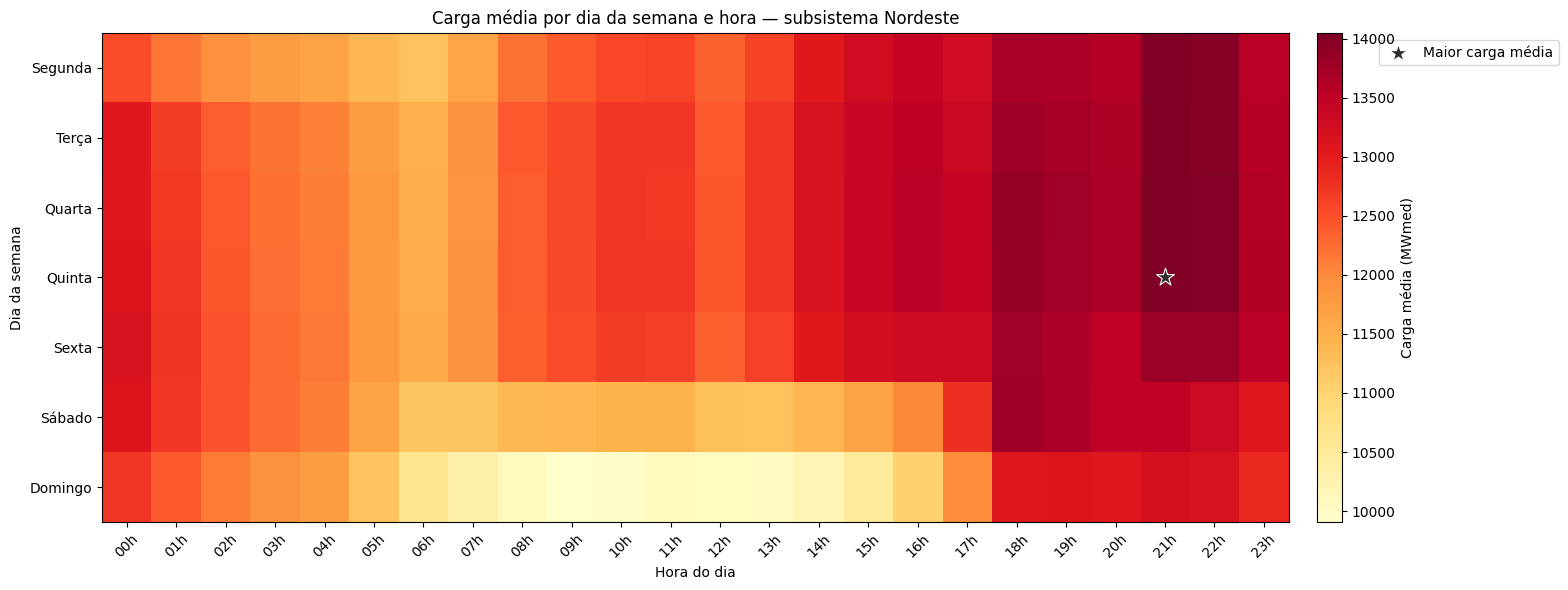

In [42]:
heatmap_weekday_labels = [
    'Segunda', 'Terça', 'Quarta', 'Quinta',
    'Sexta', 'Sábado', 'Domingo',
]

load_heatmap = (
    base.assign(
        day_of_week=base['timestamp'].dt.dayofweek,
        hour=base['timestamp'].dt.hour,
    )
    .groupby(['day_of_week', 'hour'])['load_mw']
    .mean()
    .unstack('hour')
    .reindex(index=range(7), columns=range(24))
)

fig, ax = plt.subplots(figsize=(16, 6))
image = ax.imshow(load_heatmap, aspect='auto', cmap='YlOrRd')
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label('Carga média (MWmed)')

ax.set_title('Carga média por dia da semana e hora — subsistema Nordeste')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Dia da semana')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{hour:02d}h' for hour in range(24)], rotation=45)
ax.set_yticks(range(7))
ax.set_yticklabels(heatmap_weekday_labels)

max_row, max_column = np.unravel_index(
    np.nanargmax(load_heatmap.to_numpy()),
    load_heatmap.shape,
)
ax.scatter(
    max_column,
    max_row,
    marker='*',
    s=180,
    color='#2F2F2F',
    edgecolor='white',
    linewidth=0.8,
    label='Maior carga média',
)
ax.legend(loc='upper left', bbox_to_anchor=(1.07, 1.0))

plt.tight_layout()
plt.show()

## Heatmap de correlação das variáveis

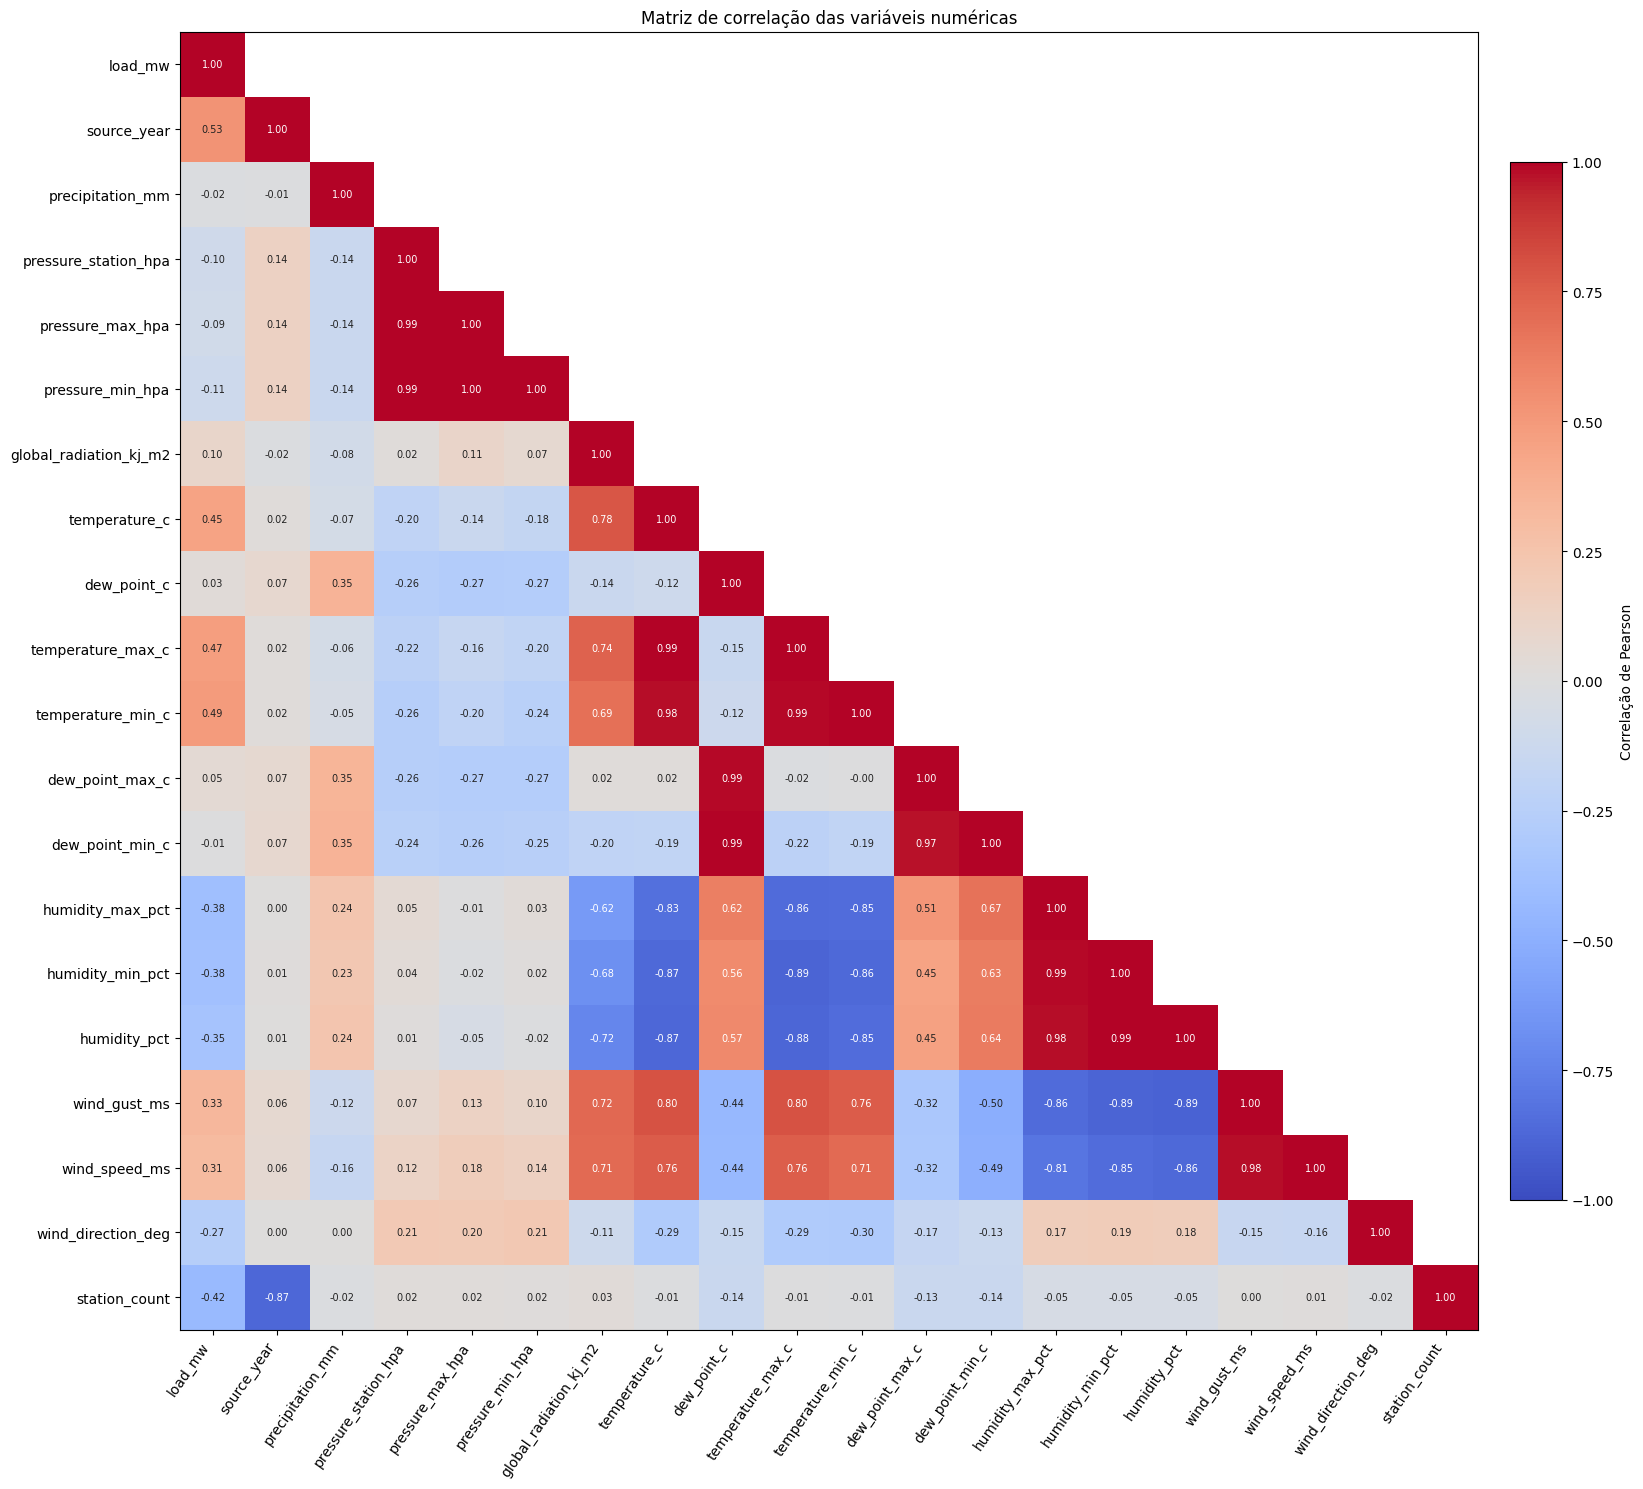

In [43]:
import numpy as np

correlation_variables = base.select_dtypes(include='number').columns.tolist()
correlation_matrix = base[correlation_variables].corr(method='pearson')

upper_triangle = np.triu(
    np.ones(correlation_matrix.shape, dtype=bool),
    k=1,
)
masked_correlations = np.ma.masked_where(
    upper_triangle,
    correlation_matrix.to_numpy(),
)

correlation_cmap = plt.colormaps['coolwarm'].copy()
correlation_cmap.set_bad(color='white')

fig, ax = plt.subplots(figsize=(18, 15))
image = ax.imshow(
    masked_correlations,
    cmap=correlation_cmap,
    vmin=-1,
    vmax=1,
)
colorbar = fig.colorbar(image, ax=ax, shrink=0.8, pad=0.02)
colorbar.set_label('Correlação de Pearson')

ax.set_xticks(range(len(correlation_variables)))
ax.set_yticks(range(len(correlation_variables)))
ax.set_xticklabels(correlation_variables, rotation=55, ha='right')
ax.set_yticklabels(correlation_variables)
ax.set_title('Matriz de correlação das variáveis numéricas')

for row in range(len(correlation_variables)):
    for column in range(len(correlation_variables)):
        if upper_triangle[row, column]:
            continue
        correlation_value = correlation_matrix.iloc[row, column]
        if np.isnan(correlation_value):
            continue
        text_color = 'white' if abs(correlation_value) >= 0.55 else '#222222'
        ax.text(
            column,
            row,
            f'{correlation_value:.2f}',
            ha='center',
            va='center',
            fontsize=7,
            color=text_color,
        )

ax.set_xlim(-0.5, len(correlation_variables) - 0.5)
ax.set_ylim(len(correlation_variables) - 0.5, -0.5)
plt.tight_layout()
plt.show()

# Autocorrelação

,lag_hours,lag,autocorrelation
0,1,t-1h,0.9695
1,2,t-2h,0.9081
2,24,t-24h,0.8183
3,48,t-48h,0.6958
4,168,t-168h,0.9069


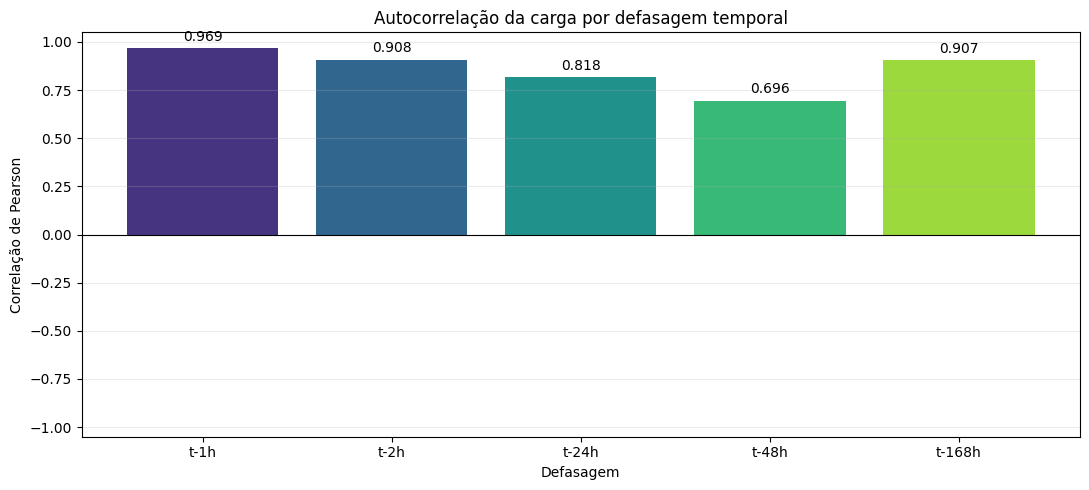

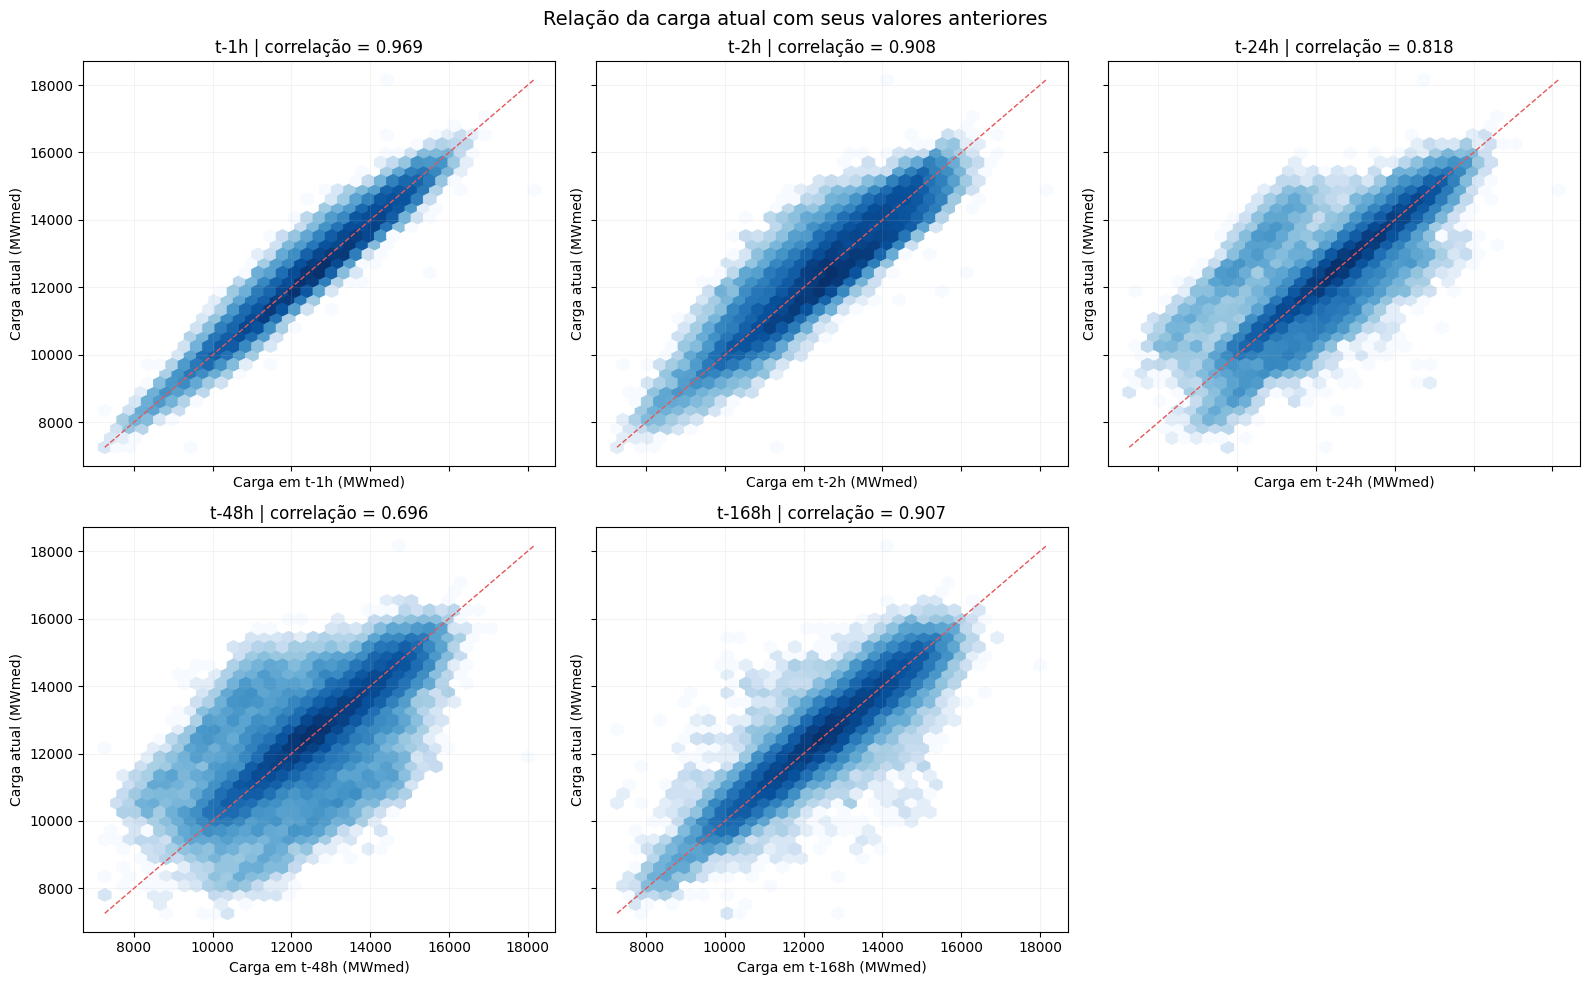

In [44]:
import numpy as np
import pandas as pd
from IPython.display import display

load_lags_hours = [1, 2, 24, 48, 168]
load_lagged = (
    base[['timestamp', 'load_mw']]
    .sort_values('timestamp')
    .reset_index(drop=True)
)

for lag in load_lags_hours:
    load_lagged[f'load_t_minus_{lag}h'] = load_lagged['load_mw'].shift(lag)

load_autocorrelation = pd.DataFrame({
    'lag_hours': load_lags_hours,
    'lag': [f't-{lag}h' for lag in load_lags_hours],
    'autocorrelation': [
        load_lagged['load_mw'].corr(load_lagged[f'load_t_minus_{lag}h'])
        for lag in load_lags_hours
    ],
})
display(load_autocorrelation.round({'autocorrelation': 4}))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(
    load_autocorrelation['lag'],
    load_autocorrelation['autocorrelation'],
    color=plt.cm.viridis(np.linspace(0.15, 0.85, len(load_lags_hours))),
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(-1.05, 1.05)
ax.set_title('Autocorrelação da carga por defasagem temporal')
ax.set_xlabel('Defasagem')
ax.set_ylabel('Correlação de Pearson')
ax.grid(True, axis='y', alpha=0.25)
ax.bar_label(bars, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lag in zip(axes, load_lags_hours):
    lag_column = f'load_t_minus_{lag}h'
    lag_pairs = load_lagged[['load_mw', lag_column]].dropna()
    correlation = load_autocorrelation.loc[
        load_autocorrelation['lag_hours'].eq(lag),
        'autocorrelation',
    ].iloc[0]
    ax.hexbin(
        lag_pairs[lag_column],
        lag_pairs['load_mw'],
        gridsize=35,
        mincnt=1,
        bins='log',
        cmap='Blues',
    )
    lower = min(lag_pairs[lag_column].min(), lag_pairs['load_mw'].min())
    upper = max(lag_pairs[lag_column].max(), lag_pairs['load_mw'].max())
    ax.plot([lower, upper], [lower, upper], '--', color='#E45756', linewidth=1)
    ax.set_title(f't-{lag}h | correlação = {correlation:.3f}')
    ax.set_xlabel(f'Carga em t-{lag}h (MWmed)')
    ax.set_ylabel('Carga atual (MWmed)')
    ax.grid(True, alpha=0.15)

axes[-1].axis('off')
fig.suptitle('Relação da carga atual com seus valores anteriores', fontsize=14)
plt.tight_layout()
plt.show()

## Rampas horárias de carga

,statistic,ramp_mw
0,Média,0.11
1,Desvio-padrão,373.17
2,P90,489.00
3,P95,655.42
4,P97,795.92
5,P99,1085.02


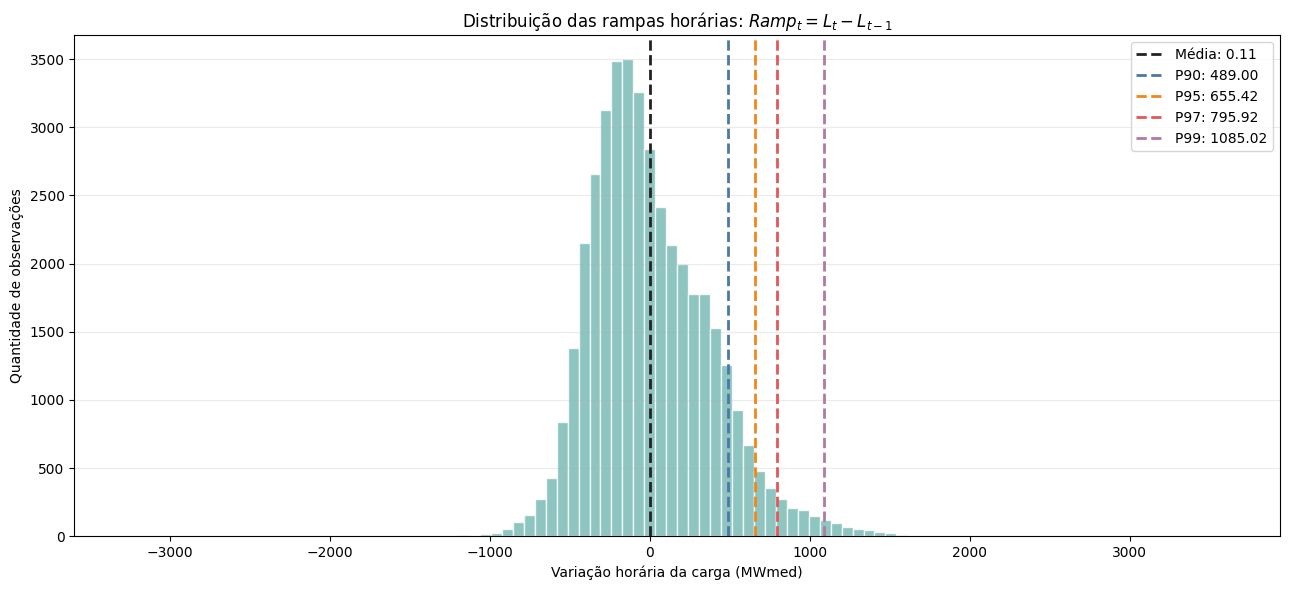

In [45]:
import pandas as pd
from IPython.display import display

load_ramps = (
    base[['timestamp', 'load_mw']]
    .sort_values('timestamp')
    .reset_index(drop=True)
)
load_ramps['ramp_mw'] = load_ramps['load_mw'].diff()
ramp_values = load_ramps['ramp_mw'].dropna()

ramp_statistics = pd.DataFrame({
    'statistic': ['Média', 'Desvio-padrão', 'P90', 'P95', 'P97', 'P99'],
    'ramp_mw': [
        ramp_values.mean(),
        ramp_values.std(),
        ramp_values.quantile(0.90),
        ramp_values.quantile(0.95),
        ramp_values.quantile(0.97),
        ramp_values.quantile(0.99),
    ],
})
display(ramp_statistics.round({'ramp_mw': 2}))

ramp_percentiles = ramp_statistics.set_index('statistic')['ramp_mw']
percentile_colors = {
    'P90': '#4C78A8',
    'P95': '#F58518',
    'P97': '#E45756',
    'P99': '#B279A2',
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(
    ramp_values,
    bins=100,
    color='#72B7B2',
    alpha=0.8,
    edgecolor='white',
)
ax.axvline(
    ramp_values.mean(),
    color='#222222',
    linestyle='--',
    linewidth=2,
    label=f'Média: {ramp_values.mean():.2f}',
)

for percentile, color in percentile_colors.items():
    value = ramp_percentiles[percentile]
    ax.axvline(
        value,
        color=color,
        linestyle='--',
        linewidth=2,
        label=f'{percentile}: {value:.2f}',
    )

ax.set_title(r'Distribuição das rampas horárias: $Ramp_t = L_t - L_{t-1}$')
ax.set_xlabel('Variação horária da carga (MWmed)')
ax.set_ylabel('Quantidade de observações')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Percentis inferiores das rampas horárias

,statistic,ramp_mw
0,P10,-418.90
1,P5,-507.85
2,P3,-568.67
3,P1,-710.87


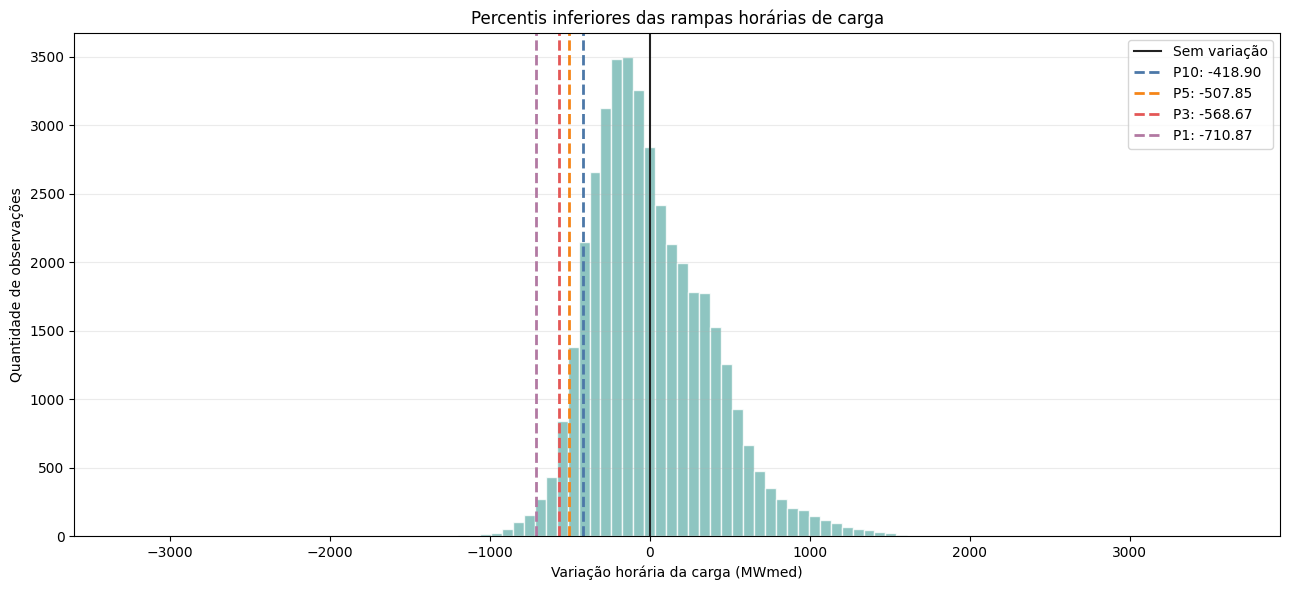

In [46]:
import pandas as pd
from IPython.display import display

negative_load_ramps = (
    base[['timestamp', 'load_mw']]
    .sort_values('timestamp')
    .reset_index(drop=True)
)
negative_load_ramps['ramp_mw'] = negative_load_ramps['load_mw'].diff()
negative_ramp_values = negative_load_ramps['ramp_mw'].dropna()

lower_ramp_statistics = pd.DataFrame({
    'statistic': ['P10', 'P5', 'P3', 'P1'],
    'ramp_mw': [
        negative_ramp_values.quantile(0.10),
        negative_ramp_values.quantile(0.05),
        negative_ramp_values.quantile(0.03),
        negative_ramp_values.quantile(0.01),
    ],
})
display(lower_ramp_statistics.round({'ramp_mw': 2}))

lower_ramp_percentiles = lower_ramp_statistics.set_index('statistic')['ramp_mw']
lower_percentile_colors = {
    'P10': '#4C78A8',
    'P5': '#F58518',
    'P3': '#E45756',
    'P1': '#B279A2',
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(
    negative_ramp_values,
    bins=100,
    color='#72B7B2',
    alpha=0.8,
    edgecolor='white',
)
ax.axvline(0, color='#222222', linewidth=1.5, label='Sem variação')

for percentile, color in lower_percentile_colors.items():
    value = lower_ramp_percentiles[percentile]
    ax.axvline(
        value,
        color=color,
        linestyle='--',
        linewidth=2,
        label=f'{percentile}: {value:.2f}',
    )

ax.set_title('Percentis inferiores das rampas horárias de carga')
ax.set_xlabel('Variação horária da carga (MWmed)')
ax.set_ylabel('Quantidade de observações')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Picos de carga

,percentile,load_mw,hours_above,percentage_above
0,P90,14531.18,4090,10.0
1,P95,14929.50,2045,5.0
2,P97,15150.98,1227,3.0
3,P99,15529.36,409,1.0


,timestamp,load_mw
0,2024-02-08 10:00:00,18156.97
1,2026-02-04 22:00:00,16987.37
2,2026-02-04 21:00:00,16823.36
3,2026-02-03 22:00:00,16619.25
4,2026-02-04 23:00:00,16594.84
5,2024-11-10 00:00:00,16468.33
6,2026-02-03 21:00:00,16461.93
7,2025-11-18 22:00:00,16446.62
8,2026-05-06 18:00:00,16426.14
9,2025-11-06 23:00:00,16415.69


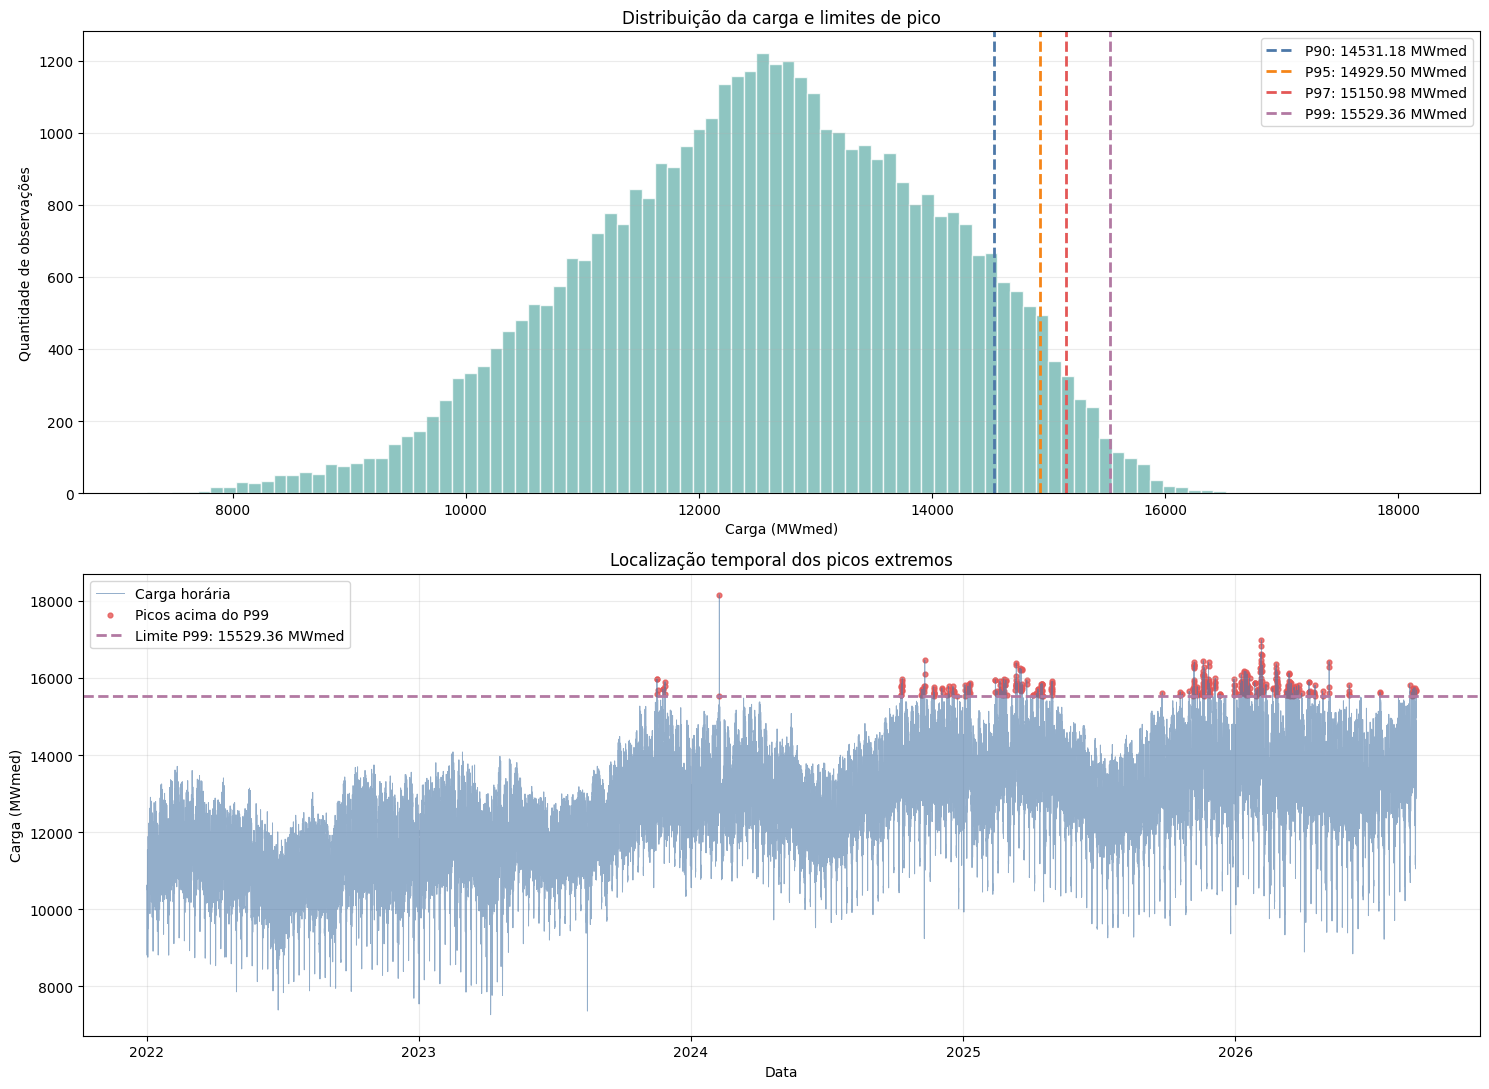

In [47]:
import pandas as pd
from IPython.display import display

load_peak_data = (
    base[['timestamp', 'load_mw']]
    .dropna(subset=['load_mw'])
    .sort_values('timestamp')
    .reset_index(drop=True)
)

load_peak_quantiles = {
    'P90': 0.90,
    'P95': 0.95,
    'P97': 0.97,
    'P99': 0.99,
}
load_peak_thresholds = {
    percentile: load_peak_data['load_mw'].quantile(quantile)
    for percentile, quantile in load_peak_quantiles.items()
}

load_peak_statistics = pd.DataFrame([
    {
        'percentile': percentile,
        'load_mw': threshold,
        'hours_above': int((load_peak_data['load_mw'] > threshold).sum()),
        'percentage_above': 100 * (load_peak_data['load_mw'] > threshold).mean(),
    }
    for percentile, threshold in load_peak_thresholds.items()
])
display(
    load_peak_statistics.round({
        'load_mw': 2,
        'percentage_above': 2,
    })
)

top_load_peaks = load_peak_data.nlargest(10, 'load_mw').reset_index(drop=True)
display(top_load_peaks.round({'load_mw': 2}))

peak_colors = {
    'P90': '#4C78A8',
    'P95': '#F58518',
    'P97': '#E45756',
    'P99': '#B279A2',
}

fig, axes = plt.subplots(2, 1, figsize=(15, 11))
axes[0].hist(
    load_peak_data['load_mw'],
    bins=100,
    color='#72B7B2',
    alpha=0.8,
    edgecolor='white',
)
for percentile, threshold in load_peak_thresholds.items():
    axes[0].axvline(
        threshold,
        color=peak_colors[percentile],
        linestyle='--',
        linewidth=2,
        label=f'{percentile}: {threshold:.2f} MWmed',
    )
axes[0].set_title('Distribuição da carga e limites de pico')
axes[0].set_xlabel('Carga (MWmed)')
axes[0].set_ylabel('Quantidade de observações')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.25)

p99_threshold = load_peak_thresholds['P99']
p99_peaks = load_peak_data[load_peak_data['load_mw'] > p99_threshold]
axes[1].plot(
    load_peak_data['timestamp'],
    load_peak_data['load_mw'],
    color='#4C78A8',
    linewidth=0.7,
    alpha=0.6,
    label='Carga horária',
)
axes[1].scatter(
    p99_peaks['timestamp'],
    p99_peaks['load_mw'],
    color='#E45756',
    s=12,
    alpha=0.8,
    label='Picos acima do P99',
)
axes[1].axhline(
    p99_threshold,
    color='#B279A2',
    linestyle='--',
    linewidth=2,
    label=f'Limite P99: {p99_threshold:.2f} MWmed',
)
axes[1].set_title('Localização temporal dos picos extremos')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Carga (MWmed)')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()